In [ ]:
#Data manipulation and analysis libraries
import pandas as pd
import numpy as np 
#Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset and display the first few rows
df = pd.read_csv("data\Mobile_price_classification.csv")
display(df.head())

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


EDA and data cleaning

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_screen   2000

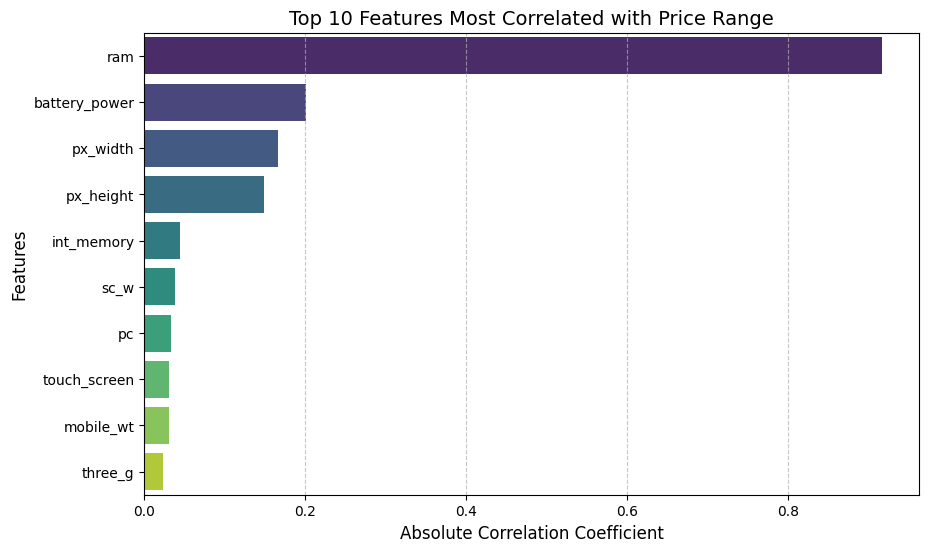

In [39]:

# 1. Check dataset info and missing values
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
# Note: This Kaggle dataset is usually pre-cleaned and has 0 missing values!

# 2. Let's look at the correlation of features with the target variable ('price_range')
# Calculate correlation with target and take the absolute values
correlations = df.corr()['price_range'].drop('price_range') # Drop target itself
top_10_corr = correlations.abs().sort_values(ascending=False).head(10)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_corr.values, y=top_10_corr.index, palette='viridis')

plt.title('Top 10 Features Most Correlated with Price Range', fontsize=14)
plt.xlabel('Absolute Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Train Test Split


In [7]:
# Separate features (X) and target (y)
X = df.drop('price_range', axis=1)
y = df['price_range']

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (1600, 20)
Testing data shape: (400, 20)


Decision Tree

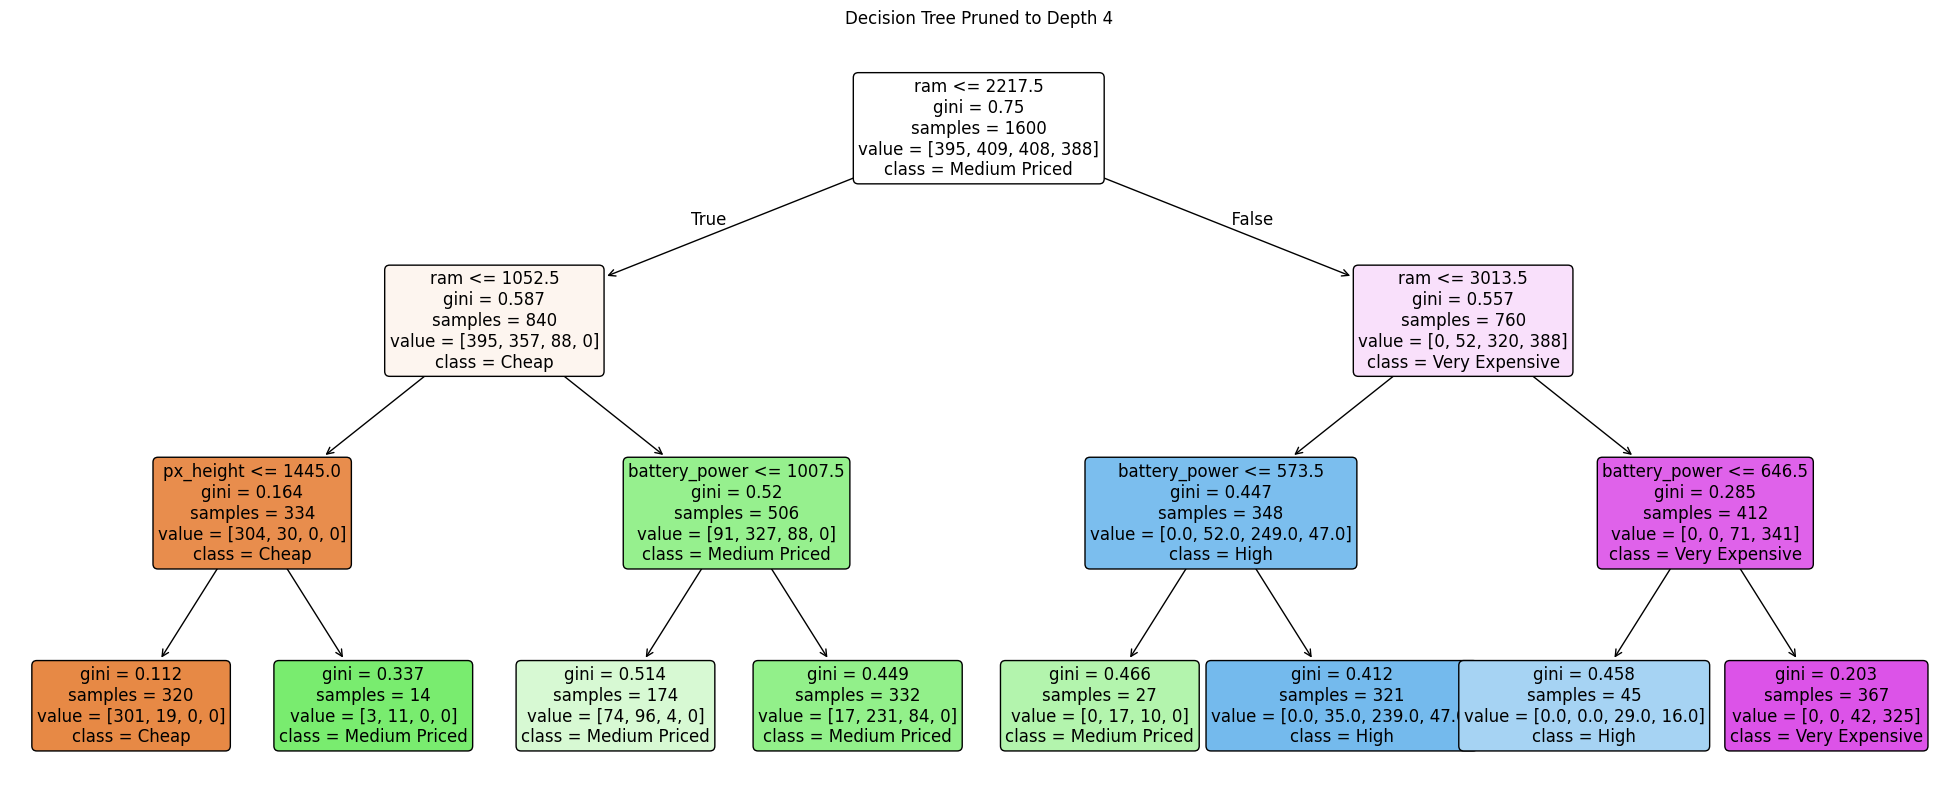

In [30]:
from sklearn import tree

# Initialize the model
pruned_decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
# Train the model
pruned_decision_tree.fit(X_train, y_train)

# Make predictions on the unseen test data
dt_preds = pruned_decision_tree.predict(X_test)

# 2. Plot it with better formatting
plt.figure(figsize=(25, 10))
tree.plot_tree(pruned_decision_tree, 
               feature_names=list(X.columns), 
               class_names=['Cheap', 'Medium Priced', 'High', 'Very Expensive'], 
               filled=True, 
               rounded=True, 
               fontsize=12)

plt.title("Decision Tree Pruned to Depth 4")
plt.show()

In [31]:
# Evaluate Performance
print("=== Decision Tree Performance ===")
print(f"Accuracy: {accuracy_score(y_test, dt_preds):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, dt_preds))


=== Decision Tree Performance ===
Accuracy: 0.7400

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84       105
           1       0.61      0.80      0.70        91
           2       0.59      0.64      0.61        92
           3       0.87      0.76      0.81       112

    accuracy                           0.74       400
   macro avg       0.76      0.74      0.74       400
weighted avg       0.77      0.74      0.75       400



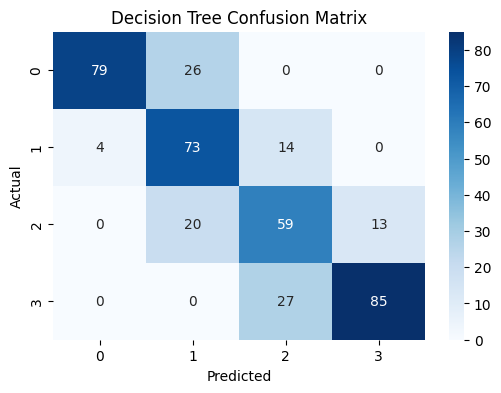

In [32]:
# Plot Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, dt_preds), annot=True, cmap='Blues', fmt='g')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

Hyper Parameter Tuning:

In [38]:
from sklearn.model_selection import GridSearchCV

# Tuning the Decision Tree specifically
dt_params = {
    'max_depth': [3, 5, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4]
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_params, cv=5)
dt_grid.fit(X_train, y_train)

print(f"Best DT Params: {dt_grid.best_params_}")
print(f"Best DT Accuracy: {dt_grid.best_score_:.4f}")

Best DT Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4}
Best DT Accuracy: 0.8556
